# Train1 COVID-19 Twitter to Midterm

Plots cross-dataset eval runs where the pretrained checkpoint came from `covid19_twitter` train1 and the target dataset is `midterm`.

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import wandb

PROJECT = "eibl-usc/graph-clip"
TRAIN_DATASET = "midterm"
EVAL_DATASET = "midterm"
TRAIN_PREFIX = "state/train1_covid19_twitter_"
EVAL_TASKS = ["nm", "lp", "pl"]
TITLE = "COVID-19 -> Ukraine/Russia"

api = wandb.Api()
runs = api.runs(PROJECT, order="-created_at", per_page=100, lazy=False)


In [62]:
rows = []
for run in runs[:250]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
    })
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(covid19_twitter|midterm|ukr_rus_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']

### covid -> ukr rus

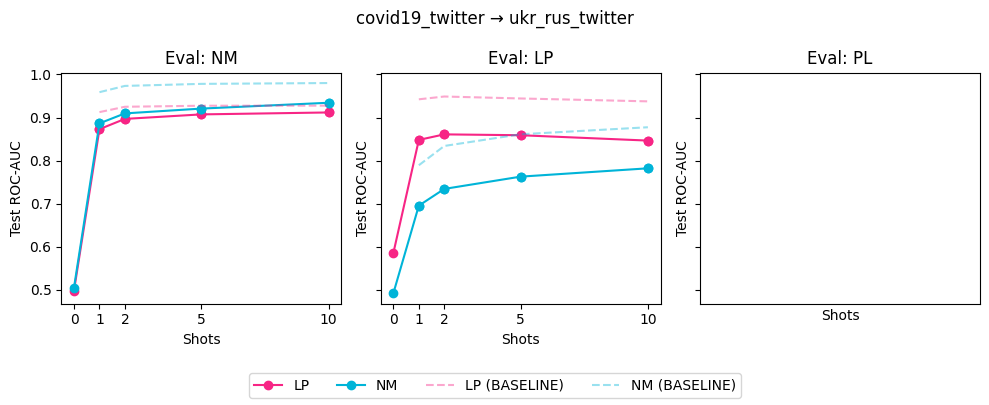

In [59]:
TRAIN_DATASET = 'covid19_twitter'
EVAL_DATASET = 'ukr_rus_twitter'
import matplotlib.pyplot as plt

colors = {
    "nm": "#00b4d8",
    "lp": "#f72585",
    "pl": "#80b918"
}
EVAL_TASKS = ["nm", "lp", "pl"]

# --- Data ---
i_cross = df.train1_dataset.eq(TRAIN_DATASET) & df.eval1_dataset.eq(EVAL_DATASET)
plot_df_cross = df[i_cross].copy()

i_same = df.train1_dataset.eq(EVAL_DATASET) & df.eval1_dataset.eq(EVAL_DATASET) & df.prefix.str.startswith("trained")
plot_df_same = df[i_same].dropna()

# --- Plot ---
fig, axes = plt.subplots(1, len(EVAL_TASKS), figsize=(10, 4), sharey=True)
if len(EVAL_TASKS) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, EVAL_TASKS):
    # Cross-dataset lines (solid)
    subset_cross = plot_df_cross[plot_df_cross["eval1_task"] == eval_task]
    for train_task in sorted(subset_cross["train1_task"].dropna().unique()):
        sub = subset_cross[subset_cross["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="o", label=f"{train_task}",
                color=colors.get(train_task), linestyle="-")

    # Same-dataset baseline lines (dashed)
    subset_same = plot_df_same[plot_df_same["eval1_task"] == eval_task]
    for train_task in sorted(subset_same["train1_task"].dropna().unique()):
        sub = subset_same[subset_same["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="", label=f"{train_task} (baseline)",
                color=colors.get(train_task), linestyle="--", alpha=0.4)

    ax.set_title(f"Eval: {eval_task.upper()}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Test ROC-AUC")
    all_shots = pd.concat([subset_cross, subset_same])["shot_label"].dropna().unique()
    ax.set_xticks(sorted(all_shots))

handles, labels = axes[0].get_legend_handles_labels()
labels = [x.upper() for x in labels]
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))

fig.suptitle(f"{TRAIN_DATASET} → {EVAL_DATASET}")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [64]:
models = plot_df_cross.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()

models = plot_df_same.pretrained_model_run.value_counts().index.str.split('/').str[1]
df[df.display_name.isin(models)][['display_name', 'dataset', 'task_name', 'n_way', 'n_shots', 'n_query']].to_clipboard()

In [83]:
(plot_df_cross.pretrained_model_run.value_counts(),
plot_df_same.pretrained_model_run.value_counts())

(pretrained_model_run
 state/train1_ukr_rus_twitter_nm_01_04_2026_13_21_56/checkpoint/state_dict_3000.ckpt    10
 state/train1_ukr_rus_twitter_lp_01_04_2026_13_22_05/state_dict                         10
 Name: count, dtype: int64,
 pretrained_model_run
 state/train1_covid19_twitter_lp_02_04_2026_17_29_30/checkpoint/state_dict_7000.ckpt    10
 state/train1_covid19_twitter_nm_02_04_2026_16_44_27/checkpoint/state_dict_6000.ckpt    10
 Name: count, dtype: int64)

### ukr-rus -> covid

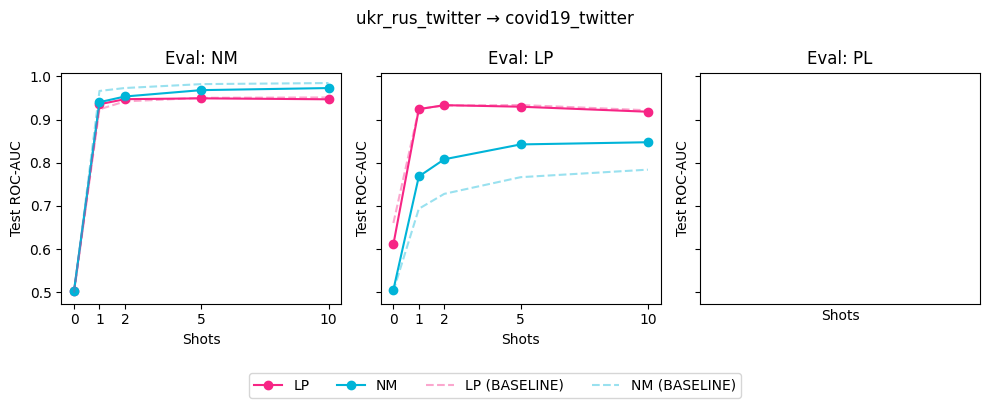

In [60]:
TRAIN_DATASET = 'ukr_rus_twitter'
EVAL_DATASET = 'covid19_twitter'

import matplotlib.pyplot as plt

colors = {
    "nm": "#00b4d8",
    "lp": "#f72585",
    "pl": "#80b918"
}
EVAL_TASKS = ["nm", "lp", "pl"]

# --- Data ---
i_cross = df.train1_dataset.eq(TRAIN_DATASET) & df.eval1_dataset.eq(EVAL_DATASET)
plot_df_cross = df[i_cross].copy()

i_same = df.train1_dataset.eq(EVAL_DATASET) & df.eval1_dataset.eq(EVAL_DATASET) & df.prefix.str.startswith("trained")
plot_df_same = df[i_same].dropna()

# --- Plot ---
fig, axes = plt.subplots(1, len(EVAL_TASKS), figsize=(10, 4), sharey=True)
if len(EVAL_TASKS) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, EVAL_TASKS):
    # Cross-dataset lines (solid)
    subset_cross = plot_df_cross[plot_df_cross["eval1_task"] == eval_task]
    for train_task in sorted(subset_cross["train1_task"].dropna().unique()):
        sub = subset_cross[subset_cross["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="o", label=f"{train_task}",
                color=colors.get(train_task), linestyle="-")

    # Same-dataset baseline lines (dashed)
    subset_same = plot_df_same[plot_df_same["eval1_task"] == eval_task]
    for train_task in sorted(subset_same["train1_task"].dropna().unique()):
        sub = subset_same[subset_same["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"],
                marker="", label=f"{train_task} (baseline)",
                color=colors.get(train_task), linestyle="--", alpha=0.4)

    ax.set_title(f"Eval: {eval_task.upper()}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Test ROC-AUC")
    all_shots = pd.concat([subset_cross, subset_same])["shot_label"].dropna().unique()
    ax.set_xticks(sorted(all_shots))

handles, labels = axes[0].get_legend_handles_labels()
labels = [x.upper() for x in labels]
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))

fig.suptitle(f"{TRAIN_DATASET} → {EVAL_DATASET}")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()